# Stationary Regime Oxygen Diffusion
## Pulmonary Acinus Modeling

This notebook solves stationary oxygen diffusion in a 2D model of the acinus with finite differences.

The domain is the square $[0, L]^2$. With $u = C - C_b$:

$$\Delta u = 0$$

| Boundary | Physiology | Condition |
|---|---|---|
| top, $y = L$ | alveolar air | Dirichlet: $u = C_a - C_b$ |
| bottom, $y = 0$ | alveolar membrane / capillaries | Robin: $\partial u / \partial n = -u / \Lambda$ |
| sides, $x = 0, L$ | symmetry | Neumann: $\partial u / \partial n = 0$ |

The screening length $\Lambda = D / W$ compares diffusion in air ($D$) with the membrane permeability ($W$).

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

# Make the package importable without installing it (pip install -e . also works)
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

from acinus_diffusion import (PhysicalConstants as P, analytical_oxygen_flux,
                              analytical_stationary_solution, calculate_oxygen_flux,
                              grid_spacing, solve_stationary_diffusion)

print("Stationary Oxygen Diffusion in Pulmonary Acinus")
print("=" * 50)

Stationary Oxygen Diffusion in Pulmonary Acinus


## 1. Physical Parameters

In [2]:
print(f"O2 diffusion coefficient in air: {P.D_O2_AIR:.2e} m²/s")
print(f"Alveolar concentration C_a:      {P.C_AIR} mol/m³")
print(f"Blood concentration C_b:         {P.C_BLOOD:.2e} mol/m³")
print(f"Screening length Λ:              {P.LAMBDA_TYPICAL} m")
print(f"Membrane permeability W = D/Λ:   {P.W_MEMBRANE:.2e} m/s")

O2 diffusion coefficient in air: 2.00e-05 m²/s
Alveolar concentration C_a:      8.4 mol/m³
Blood concentration C_b:         5.10e-04 mol/m³
Screening length Λ:              0.28 m
Membrane permeability W = D/Λ:   7.14e-05 m/s


## 2. Basic Simulation

In [3]:
N, M = 100, 100
L = 0.01  # 1 cm domain

concentration = solve_stationary_diffusion(N, M, L)
dx, dy = grid_spacing(N, M, L)

x = np.linspace(0, L, N)
y = np.linspace(0, L, M)
X, Y = np.meshgrid(x, y)

print(f"Solution shape: {concentration.shape}")
print(f"Min concentration: {concentration.min():.4f} mol/m³")
print(f"Max concentration: {concentration.max():.4f} mol/m³")

Solution shape: (100, 100)
Min concentration: 8.1104 mol/m³
Max concentration: 8.4000 mol/m³


## 3. Visualization

With uniform top and bottom conditions and no-flux side walls the problem is one-dimensional. The exact solution is linear in $y$:

$$C(y) = C_b + (C_a - C_b)\,\frac{y + \Lambda}{L + \Lambda}$$

Because $\Lambda \gg L$, the concentration drops only slightly across the domain: most of the resistance to oxygen transfer is in the membrane.

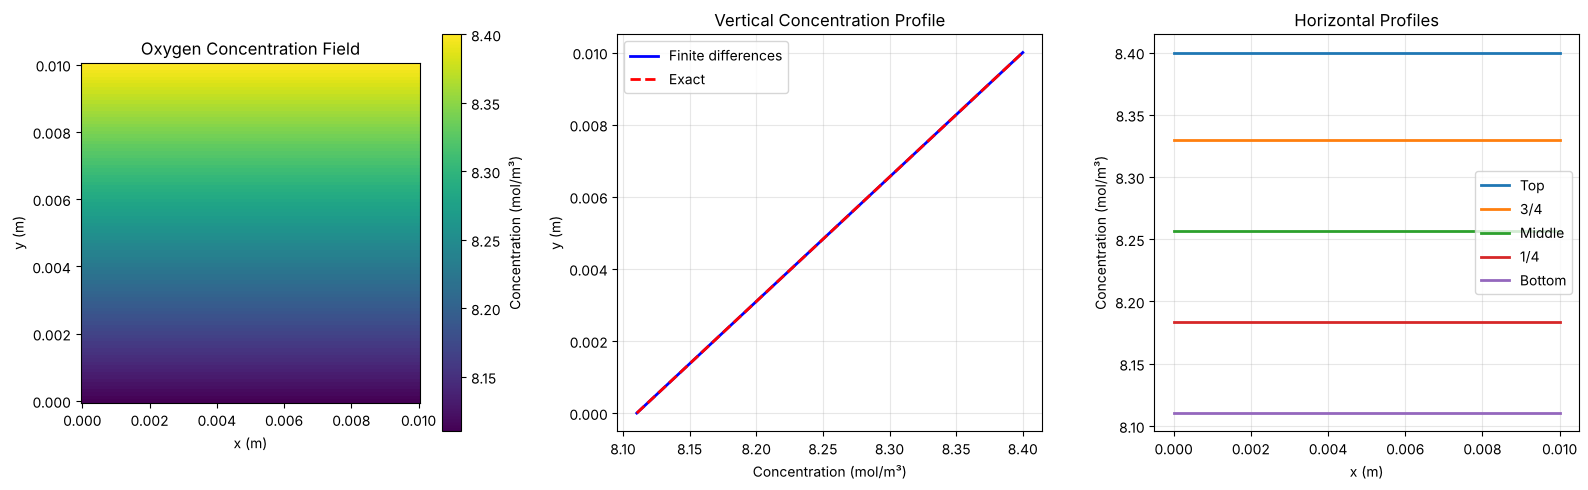

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Concentration field
im = axes[0].pcolormesh(X, Y, concentration, shading='auto', cmap='viridis')
fig.colorbar(im, ax=axes[0], label='Concentration (mol/m³)')
axes[0].set_xlabel('x (m)')
axes[0].set_ylabel('y (m)')
axes[0].set_title('Oxygen Concentration Field')
axes[0].set_aspect('equal')

# Plot 2: Vertical profile against the exact solution
axes[1].plot(concentration[:, N // 2], y, 'b-', linewidth=2, label='Finite differences')
axes[1].plot(analytical_stationary_solution(y, L), y, 'r--', linewidth=2, label='Exact')
axes[1].set_xlabel('Concentration (mol/m³)')
axes[1].set_ylabel('y (m)')
axes[1].set_title('Vertical Concentration Profile')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Horizontal profiles at different heights (flat: the problem is 1D)
heights = [M - 1, 3 * M // 4, M // 2, M // 4, 0]
labels = ['Top', '3/4', 'Middle', '1/4', 'Bottom']
for h, label in zip(heights, labels):
    axes[2].plot(x, concentration[h, :], label=label, linewidth=2)
axes[2].set_xlabel('x (m)')
axes[2].set_ylabel('Concentration (mol/m³)')
axes[2].set_title('Horizontal Profiles')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 4. Screening Length Effect Study

The oxygen flux absorbed by the capillaries (per unit depth) is

$$\Phi = \int_0^L W\,u(x, 0)\,dx = D\,(C_a - C_b)\,\frac{L}{L + \Lambda}$$

* $\Lambda \ll L$ — **diffusion-limited**: $\Phi \to D (C_a - C_b)$, independent of the membrane.
* $\Lambda \gg L$ — **membrane-limited**: $\Phi \approx W (C_a - C_b) L$, the whole surface works.

The flux decreases monotonically with $\Lambda$, so there is no "optimal" $\Lambda$: the crossover between the two regimes is at $\Lambda = L$.

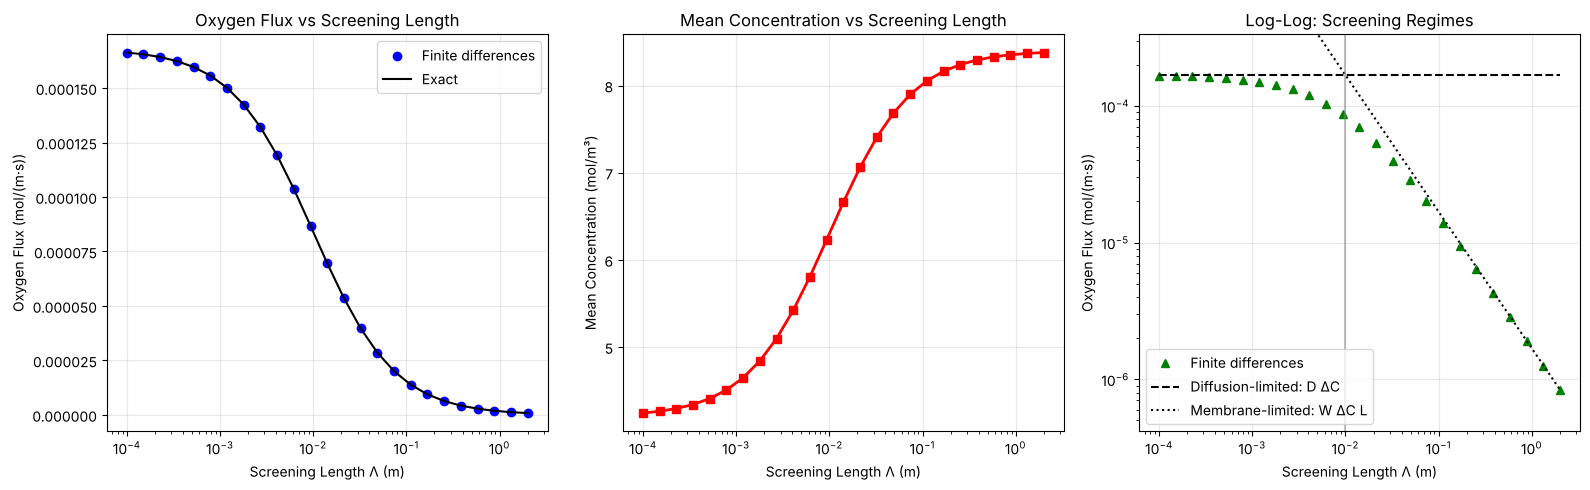

Max relative error vs exact flux: 2.0e-13
Flux at physiological Λ = 0.28 m: 5.793e-06 mol/(m·s)
Efficiency L / (L + Λ) at physiological Λ: 3.4% of the diffusion-limited flux


In [5]:
lambda_values = np.logspace(-4, np.log10(2.0), 25)
flux_values = []
mean_concentrations = []

for lambda_param in lambda_values:
    C = solve_stationary_diffusion(N, M, L, lambda_param=lambda_param)
    flux_values.append(calculate_oxygen_flux(C, dx, lambda_param))
    mean_concentrations.append(np.mean(C))

flux_values = np.array(flux_values)
flux_exact = analytical_oxygen_flux(L, lambda_param=lambda_values)
delta_C = P.C_AIR - P.C_BLOOD

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].semilogx(lambda_values, flux_values, 'bo', label='Finite differences')
axes[0].semilogx(lambda_values, flux_exact, 'k-', label='Exact')
axes[0].set_xlabel('Screening Length Λ (m)')
axes[0].set_ylabel('Oxygen Flux (mol/(m·s))')
axes[0].set_title('Oxygen Flux vs Screening Length')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogx(lambda_values, mean_concentrations, 'rs-', linewidth=2)
axes[1].set_xlabel('Screening Length Λ (m)')
axes[1].set_ylabel('Mean Concentration (mol/m³)')
axes[1].set_title('Mean Concentration vs Screening Length')
axes[1].grid(True, alpha=0.3)

axes[2].loglog(lambda_values, flux_values, 'g^', label='Finite differences')
axes[2].loglog(lambda_values, P.D_O2_AIR * delta_C * np.ones_like(lambda_values), 'k--',
               label='Diffusion-limited: D ΔC')
axes[2].loglog(lambda_values, P.D_O2_AIR / lambda_values * delta_C * L, 'k:',
               label='Membrane-limited: W ΔC L')
axes[2].axvline(L, color='gray', alpha=0.5)
axes[2].set_ylim(flux_values.min() / 2, flux_values.max() * 2)
axes[2].set_xlabel('Screening Length Λ (m)')
axes[2].set_ylabel('Oxygen Flux (mol/(m·s))')
axes[2].set_title('Log-Log: Screening Regimes')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

flux_typical = analytical_oxygen_flux(L)
print(f"Max relative error vs exact flux: {np.max(np.abs(flux_values / flux_exact - 1)):.1e}")
print(f"Flux at physiological Λ = {P.LAMBDA_TYPICAL} m: {flux_typical:.3e} mol/(m·s)")
print(f"Efficiency L / (L + Λ) at physiological Λ: {L / (L + P.LAMBDA_TYPICAL):.1%} "
      "of the diffusion-limited flux")

## 5. Validation and Computational Cost

Because the exact solution is linear in $y$, the 5-point scheme with the first-order Robin condition reproduces it exactly on every grid: the error below is at machine precision. The grid size is therefore only driven by the geometry (e.g. the lesions of the COPD notebook).

Grid  20x20 : 0.003 s, max error 2.3e-14 mol/m³
Grid  40x40 : 0.010 s, max error 9.6e-14 mol/m³
Grid  60x60 : 0.028 s, max error 1.4e-13 mol/m³
Grid  80x80 : 0.046 s, max error 4.5e-13 mol/m³
Grid 100x100: 0.079 s, max error 1.4e-12 mol/m³


Grid 150x150: 0.264 s, max error 8.5e-13 mol/m³


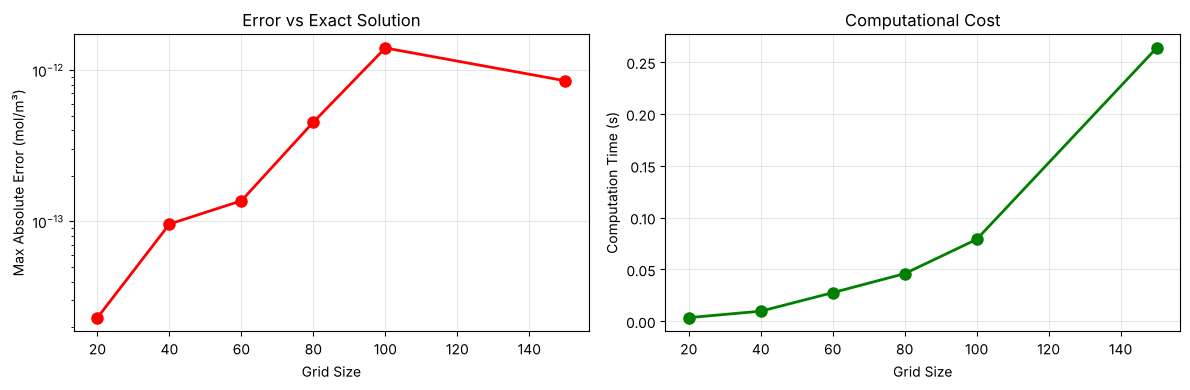

In [6]:
import time

grid_sizes = [20, 40, 60, 80, 100, 150]
errors = []
computation_times = []

for n in grid_sizes:
    start_time = time.perf_counter()
    C = solve_stationary_diffusion(n, n, L)
    computation_times.append(time.perf_counter() - start_time)

    exact = analytical_stationary_solution(np.linspace(0, L, n), L)[:, None]
    errors.append(np.max(np.abs(C - exact)))
    print(f"Grid {n:3d}x{n:<3d}: {computation_times[-1]:.3f} s, max error {errors[-1]:.1e} mol/m³")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(grid_sizes, errors, 'ro-', linewidth=2, markersize=8)
axes[0].set_xlabel('Grid Size')
axes[0].set_ylabel('Max Absolute Error (mol/m³)')
axes[0].set_title('Error vs Exact Solution')
axes[0].grid(True, alpha=0.3)

axes[1].plot(grid_sizes, computation_times, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Grid Size')
axes[1].set_ylabel('Computation Time (s)')
axes[1].set_title('Computational Cost')
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 6. Summary

* The finite-difference solver reproduces the exact stationary solution to machine precision.
* The absorbed flux $\Phi = D (C_a - C_b) L / (L + \Lambda)$ decreases with the screening length.
* At the physiological value $\Lambda \approx 28$ cm, a 1 cm domain works in the membrane-limited regime: the concentration is almost uniform and the whole exchange surface is used.

Next: the quasi-stationary regime with breathing dynamics.